## Import datasets and create data format yolo

In [ ]:
! pip install torchmetrics[detection]

In [5]:
from datasets import load_dataset
import shutil
import os
import json
ds = load_dataset("keremberke/license-plate-object-detection", "full")

KeyboardInterrupt: 

In [ ]:
def get_img_paths_info(folder_dir=''):
    image_folder = os.path.join(folder_dir, 'image')
    info_folder = os.path.join(folder_dir, 'info')
    json_files = os.listdir(info_folder)[:200]
    image_paths = os.listdir(image_folder)[:200]
    data_list = []
    for i, json_file in enumerate(json_files):
        json_path = os.path.join(info_folder, json_file)
        image_path = os.path.join(image_folder, image_paths[i])
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            img_size = [data['width'], data['height']]
            bboxs = data['objects']['bbox']
        data_list.append((image_path, img_size, bboxs))
    return data_list


# Ví dụ sử dụng:
save_dir = "../license-plate-dataset"
result = get_img_paths_info(os.path.join(save_dir, "train"))
print("Kết quả:", result)

Kết quả: [('../license-plate-dataset\\train\\image\\0.png', [472, 303], [[185.0, 231.0, 107.0, 37.0]]), ('../license-plate-dataset\\train\\image\\1.png', [472, 303], [[172.0, 95.0, 96.0, 83.0]]), ('../license-plate-dataset\\train\\image\\10.png', [472, 303], [[239.0, 139.0, 98.0, 30.0]]), ('../license-plate-dataset\\train\\image\\100.png', [472, 303], [[192.0, 34.0, 86.0, 63.0]]), ('../license-plate-dataset\\train\\image\\1000.png', [472, 303], [[156.0, 115.0, 99.0, 84.0]]), ('../license-plate-dataset\\train\\image\\1001.png', [472, 303], [[317.0, 179.0, 80.0, 53.0]]), ('../license-plate-dataset\\train\\image\\1002.png', [472, 303], [[154.0, 120.0, 92.0, 82.0]]), ('../license-plate-dataset\\train\\image\\1003.png', [472, 303], [[196.0, 101.0, 103.0, 81.0]]), ('../license-plate-dataset\\train\\image\\1004.png', [472, 303], [[215.0, 240.0, 99.0, 25.0]]), ('../license-plate-dataset\\train\\image\\1005.png', [450, 290], [[144.0, 210.0, 65.0, 49.0]]), ('../license-plate-dataset\\train\\imag

(640, 640)


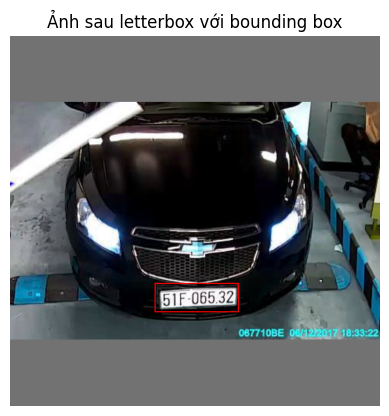

In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Hàm letterbox (như đã định nghĩa trước đó)
def letterbox(image, target, new_shape=(640, 640), color=(114, 114, 114)):
    """
    Resize ảnh theo dạng letterbox: giữ tỷ lệ gốc, resize sao cho vừa khung, thêm padding để đạt kích thước new_shape.
    Cập nhật tọa độ bounding boxes bằng cách nhân với scale và cộng thêm offset do padding.
    """
    # Chuyển PIL image thành numpy array
    image_np = np.array(image)
    h, w = image_np.shape[:2]
    new_h, new_w = new_shape

    # Tính hệ số scale: chọn scale nhỏ nhất để vừa khung (không bị co dãn)
    scale = min(new_h / h, new_w / w)
    # kích thước sau khi resize
    new_unpad = (int(round(w * scale)), int(round(h * scale)))

    # Resize ảnh
    image_resized = cv2.resize(
        image_np, new_unpad, interpolation=cv2.INTER_LINEAR)

    # Tính toán lượng padding cần thêm
    pad_w = new_w - new_unpad[0]
    pad_h = new_h - new_unpad[1]
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    # Thêm padding vào ảnh
    image_padded = cv2.copyMakeBorder(image_resized, pad_top, pad_bottom, pad_left, pad_right,
                                      cv2.BORDER_CONSTANT, value=color)

    # Cập nhật bounding boxes: giả sử boxes có định dạng [x_min, y_min, x_max, y_max]
    boxes = target["boxes"]
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.numpy()
    boxes = boxes * scale
    boxes[:, [0, 2]] += pad_left  # x_min và x_max
    boxes[:, [1, 3]] += pad_top   # y_min và y_max
    target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)

    # Chuyển ảnh từ BGR sang RGB (OpenCV dùng BGR theo mặc định)
    image_padded = cv2.cvtColor(image_padded, cv2.COLOR_BGR2RGB)
    return Image.fromarray(image_padded), target



# Lấy mẫu đầu tiên
image_path, img_size, boxes_list = result[0]

# Nếu bounding box theo định dạng [x, y, w, h], chuyển sang [x_min, y_min, x_max, y_max]
boxes_converted = []
for box in boxes_list:
    x, y, w, h = box
    boxes_converted.append([x, y, x + w, y + h])
boxes_tensor = torch.tensor(boxes_converted, dtype=torch.float32)

# Tạo target dictionary
target = {"boxes": boxes_tensor}

# Load ảnh từ file
img = Image.open(image_path).convert("RGB")

# Áp dụng hàm letterbox (với new_shape là 640x640)
img_letterboxed, target_updated = letterbox(
    img, target, new_shape=(640, 640), color=(114, 114, 114))

# Vẽ bounding box đã cập nhật lên ảnh
draw = ImageDraw.Draw(img_letterboxed)
for box in target_updated["boxes"].numpy():
    draw.rectangle(list(box), outline="red", width=2)

# Hiển thị kết quả
plt.imshow(img_letterboxed)
plt.title("Ảnh sau letterbox với bounding box")
plt.axis("off")
plt.show()

In [15]:
train_data = get_img_paths_info('../license-plate-dataset/train')
val_data = get_img_paths_info('../license-plate-dataset/validation')
test_data = get_img_paths_info('../license-plate-dataset/test')

In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import cv2
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Hàm custom_transform: Áp dụng letterbox và chuyển ảnh sang tensor
def custom_transform(image, target, new_shape=(640, 640)):
    image, target = letterbox(
        image, target, new_shape=new_shape, color=(114, 114, 114))
    image = torchvision.transforms.ToTensor()(image)
    return image, target

# Custom Dataset: Chỉ bao gồm các trường cần thiết "boxes" và "labels"
class LicensePlateDataset(Dataset):
    def __init__(self, data_list, transforms=None):
        """
        data_list: Danh sách các phần tử, mỗi phần tử là tuple:
                   (img_path, img_size, bboxes)
                   với bboxes có định dạng [[x, y, w, h], ...]
        transforms: Hàm transform nhận vào (image, target) và trả về (image, target)
        """
        self.data_list = data_list
        self.transforms = transforms

    def __getitem__(self, idx):
        img_path, img_size, bboxes = self.data_list[idx]

        # Load ảnh
        image = Image.open(img_path).convert("RGB")

        # Chuyển bounding boxes từ [x, y, w, h] sang [x_min, y_min, x_max, y_max]
        boxes_converted = []
        for box in bboxes:
            x, y, w, h = box
            boxes_converted.append([x, y, x + w, y + h])
        boxes_tensor = torch.tensor(boxes_converted, dtype=torch.float32)
        # Giả sử label của biển số luôn là 1
        labels = torch.ones((len(bboxes),), dtype=torch.int64)
        target = {"boxes": boxes_tensor, "labels": labels}

        if self.transforms is not None:
            image, target = self.transforms(image, target)
        return image, target

    def __len__(self):
        return len(self.data_list)

# Giả sử train_data và val_data đã được định nghĩa theo cấu trúc:
# train_data = [(img_path, img_size, bboxes), ...]
# Ví dụ:
# train_data = [("path/to/image1.jpg", [width, height], [[x, y, w, h], ...]), ...]
# Tương tự với val_data


# Sử dụng custom_transform vào dataset
train_dataset = LicensePlateDataset(
    train_data, transforms=lambda img, tgt: custom_transform(img, tgt, new_shape=(640, 640)))
val_dataset = LicensePlateDataset(
    val_data, transforms=lambda img, tgt: custom_transform(img, tgt, new_shape=(640, 640)))

# Tạo DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2,
                          shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=2,
                        shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Khởi tạo mô hình Faster R-CNN với backbone ResNet50-FPN pretrained
model = fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2  # Background + License Plate
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Di chuyển mô hình sang GPU (nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Setup optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Kiểm tra một batch dữ liệu
images, targets = next(iter(train_loader))
print("Kích thước batch image:", [img.shape for img in images])
print("Target mẫu:", targets[0])

d:\Asus\Ungdung\Miniconda\workspace\envs\AIOEx\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
d:\Asus\Ungdung\Miniconda\workspace\envs\AIOEx\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:51<00:00, 3.26MB/s] 


Kích thước batch image: [torch.Size([3, 640, 640]), torch.Size([3, 640, 640])]
Target mẫu: {'boxes': tensor([[250.8475, 244.1695, 364.7458, 343.1525]]), 'labels': tensor([1]), 'area': tensor([11273.9990]), 'iscrowd': tensor([0]), 'image_id': tensor([86])}


### Test torchmetrics

In [4]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def test_detection_metrics():
    # Ground-truth cho 1 ảnh: 1 bounding box với tọa độ [x_min, y_min, x_max, y_max] và label = 1
    ground_truth = [{
        "boxes": torch.tensor([[10, 10, 50, 50]]).float(),  # dạng float32
        "labels": torch.tensor([1]).int(),                   # dạng int
    }]

    # Predictions cho 1 ảnh: 1 dự đoán với box [x_min, y_min, x_max, y_max], score 0.9 và label = 1
    predictions = [{
        # box dự đoán (gần ground truth)
        "boxes": torch.tensor([[12, 12, 48, 48]]).float(),
        "scores": torch.tensor([0.9]).float(),               # confidence score
        "labels": torch.tensor([1]).int(),
    }]

    # Khởi tạo metric (MeanAveragePrecision sẽ tính toán AP với các ngưỡng IoU mặc định từ 0.5 đến 0.95)
    metric = MeanAveragePrecision()

    # Cập nhật metric với dữ liệu dự đoán và ground-truth
    metric.update(predictions, ground_truth)

    # Tính toán các chỉ số
    results = metric.compute()

    # In ra các chỉ số đánh giá
    print("Mean Average Precision (mAP):", results["map"].item())
    print("AP at IoU=0.50 (ap50):", results["map_50"].item())
    print("AP at IoU=0.75 (ap75):", results["map_75"].item())



test_detection_metrics()

Mean Average Precision (mAP): 0.699999988079071
AP at IoU=0.50 (ap50): 1.0
AP at IoU=0.75 (ap75): 1.0


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Giả sử bạn có DataLoader train_loader, val_loader
# Giả sử bạn đang xài mô hình YOLO "model" trả về loss_dict = {"loss_box", "loss_cls", "loss_dfl"}

num_epochs = 1

# Các list để lưu loss qua từng epoch
train_box_losses = []
train_cls_losses = []
train_dfl_losses = []
val_box_losses = []
val_cls_losses = []
val_dfl_losses = []

# Các list để lưu metric (Precision, Recall, mAP@0.5, mAP@0.5:0.95)
precision_list = []
recall_list = []
map50_list = []
map50_95_list = []

best_model_wts = None
best_val_loss = float('inf')

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

In [ ]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt

# Khởi tạo các biến theo dõi loss và metric
num_epochs = 10

train_cls_losses = []
train_box_losses = []
train_obj_losses = []
train_rpn_losses = []

val_cls_losses = []
val_box_losses = []
val_obj_losses = []
val_rpn_losses = []

precision_list = []
recall_list = []
map50_list = []
map50_95_list = []

best_model_wts = None
best_val_loss = float('inf')

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training and Validation Loop
for epoch in range(num_epochs):
    ####################
    # Training Phase
    ####################
    model.train()
    total_train_loss = 0.0
    epoch_train_cls_loss = 0.0
    epoch_train_box_loss = 0.0
    epoch_train_obj_loss = 0.0
    epoch_train_rpn_loss = 0.0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss_cls = loss_dict["loss_classifier"]
        loss_box = loss_dict["loss_box_reg"]
        loss_obj = loss_dict["loss_objectness"]
        loss_rpn = loss_dict["loss_rpn_box_reg"]

        total_loss = loss_cls + loss_box + loss_obj + loss_rpn

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_train_cls_loss += loss_cls.item()
        epoch_train_box_loss += loss_box.item()
        epoch_train_obj_loss += loss_obj.item()
        epoch_train_rpn_loss += loss_rpn.item()
        total_train_loss += total_loss.item()

    # Trung bình loss trên toàn bộ train_loader
    n_train = len(train_loader)
    avg_train_loss = total_train_loss / n_train
    train_cls_losses.append(epoch_train_cls_loss / n_train)
    train_box_losses.append(epoch_train_box_loss / n_train)
    train_obj_losses.append(epoch_train_obj_loss / n_train)
    train_rpn_losses.append(epoch_train_rpn_loss / n_train)

    ####################
    # Validation Phase
    ####################
    model.eval()
    total_val_loss = 0.0
    epoch_val_cls_loss = 0.0
    epoch_val_box_loss = 0.0
    epoch_val_obj_loss = 0.0
    epoch_val_rpn_loss = 0.0

    # Khởi tạo metric (TorchMetrics) cho val
    val_metric = MeanAveragePrecision()

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets_gpu = [{k: v.to(device)
                            for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets_gpu)
            loss_cls = loss_dict["loss_classifier"]
            loss_box = loss_dict["loss_box_reg"]
            loss_obj = loss_dict["loss_objectness"]
            loss_rpn = loss_dict["loss_rpn_box_reg"]

            total_loss = loss_cls + loss_box + loss_obj + loss_rpn

            epoch_val_cls_loss += loss_cls.item()
            epoch_val_box_loss += loss_box.item()
            epoch_val_obj_loss += loss_obj.item()
            epoch_val_rpn_loss += loss_rpn.item()
            total_val_loss += total_loss.item()

            # Lấy prediction để tính metric
            # Với FasterRCNN: gọi model(images) (không có targets) để nhận dự đoán
            preds = model(images)
            # Định dạng ground-truth phù hợp: lấy từ targets gốc (có thể cần chuyển .cpu())
            gt_for_metric = []
            for t in targets:
                gt_for_metric.append({
                    "boxes": t["boxes"],
                    "labels": t["labels"]
                })
            val_metric.update(preds, gt_for_metric)

    n_val = len(val_loader)
    avg_val_loss = total_val_loss / n_val
    val_cls_losses.append(epoch_val_cls_loss / n_val)
    val_box_losses.append(epoch_val_box_loss / n_val)
    val_obj_losses.append(epoch_val_obj_loss / n_val)
    val_rpn_losses.append(epoch_val_rpn_loss / n_val)

    # Tính metric trên validation
    val_results = val_metric.compute()
    # Dựa vào kết quả bạn đã xem key, ở đây chúng có dạng "map", "map_50", "map_75"
    epoch_map = float(val_results["map"])
    epoch_map50 = float(val_results["map_50"])
    # Với Precision và Recall, có thể cần tính từ map_per_class hoặc một giá trị tóm tắt,
    # nhưng TorchMetrics cung cấp tổng quan qua "map" chứ không riêng trực tiếp "precision" hay "recall"
    # Do vậy, bạn có thể lấy precision/recall từ các metric bổ sung nếu cần.
    # Ở đây, ta chỉ lưu mAP:
    map50_list.append(epoch_map50)
    map50_95_list.append(epoch_map)

    # In thông tin epoch
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.3f} (Cls: {train_cls_losses[-1]:.3f}, Box: {train_box_losses[-1]:.3f}) | "
          f"Val Loss: {avg_val_loss:.3f} (Cls: {val_cls_losses[-1]:.3f}, Box: {val_box_losses[-1]:.3f}) | "
          f"mAP@0.5: {epoch_map50:.3f}, mAP@0.5:0.95: {epoch_map:.3f}")

    # Lưu best model theo tổng loss (hoặc bạn có thể dùng mAP)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = model.state_dict()

# Sau khi training kết thúc:
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_license_plate_detector.pth')

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(num_epochs)

# Vẽ Loss Training
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_cls_losses, label="Train Cls Loss")
plt.plot(epochs_range, train_box_losses, label="Train Box Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.show()

# Vẽ Loss Validation
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_cls_losses, label="Val Cls Loss")
plt.plot(epochs_range, val_box_losses, label="Val Box Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Losses")
plt.show()

# Vẽ mAP metric
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, map50_list, label="mAP@0.5")
plt.plot(epochs_range, map50_95_list, label="mAP@0.5:0.95")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP Metrics")
plt.show()